Saved live plot for mackay to RELDEC/results/dynami_verification_1000/live_plot_mackay.png
Saved live plot for wran to RELDEC/results/dynami_verification_1000/live_plot_wran.png


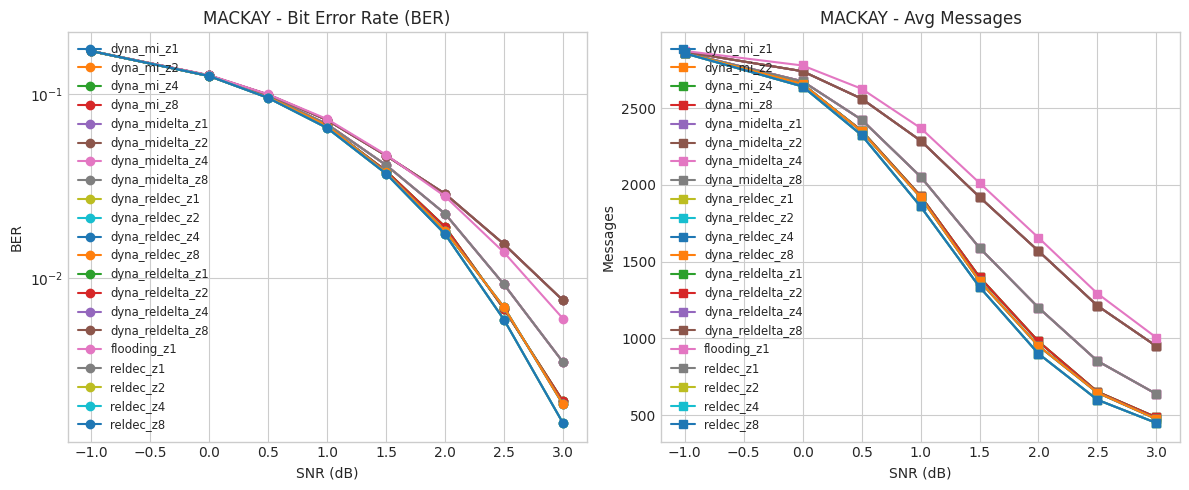

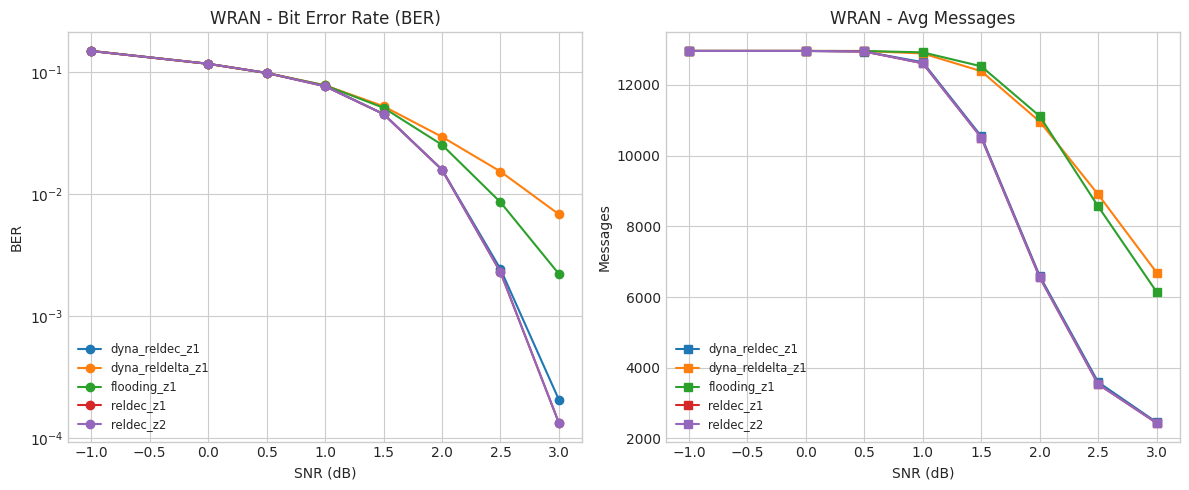

In [1]:
import pandas as pd, glob, os, matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

dfs = []
# Safely read existing completed eval files
for f in sorted(glob.glob('RELDEC/results/dynami_verification_1000/*.csv')):
    try:
        df = pd.read_csv(f)
        name = os.path.basename(f).replace('.csv', '')
        parts = name.rsplit('_z', 1)
        df['matrix'] = parts[0].split('_')[0]
        df['method_z'] = name.split('_', 1)[1] if '_' in name else name
        dfs.append(df)
    except: pass

if not dfs:
    print('No data found yet.')
    exit()

all_df = pd.concat(dfs, ignore_index=True)

for matrix in all_df['matrix'].unique():
    sub = all_df[all_df['matrix'] == matrix]
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    for method_z in sorted(sub['method_z'].unique()):
        m_df = sub[sub['method_z'] == method_z].sort_values('snr_db')
        axes[0].plot(m_df['snr_db'], m_df['ber'], marker='o', label=method_z)
        axes[1].plot(m_df['snr_db'], m_df['avg_messages'], marker='s', label=method_z)

    axes[0].set(title=f'{matrix.upper()} - Bit Error Rate (BER)', xlabel='SNR (dB)', ylabel='BER', yscale='log')
    axes[1].set(title=f'{matrix.upper()} - Avg Messages', xlabel='SNR (dB)', ylabel='Messages')
    for ax in axes: ax.legend(fontsize='small')
    
    out = f'RELDEC/results/dynami_verification_1000/live_plot_{matrix}.png'
    plt.tight_layout()
    plt.savefig(out)
    print(f'Saved live plot for {matrix} to {out}')


=== Z-SWEEP PLOTS ===


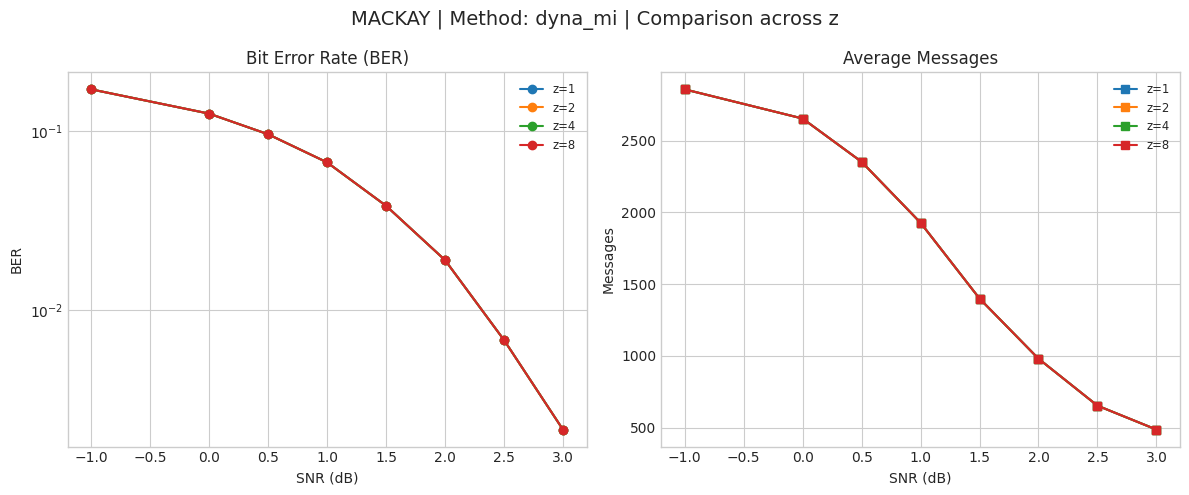

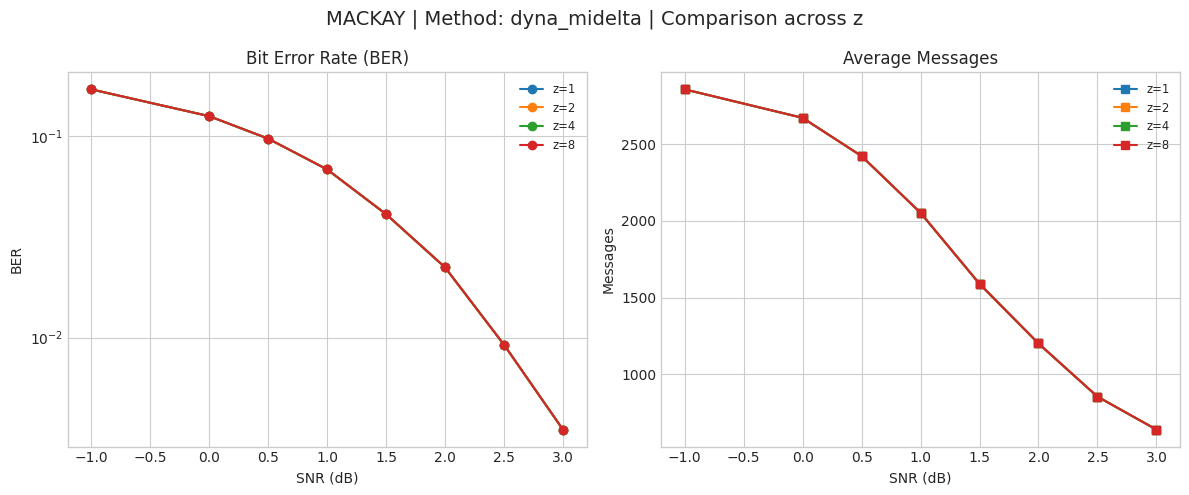

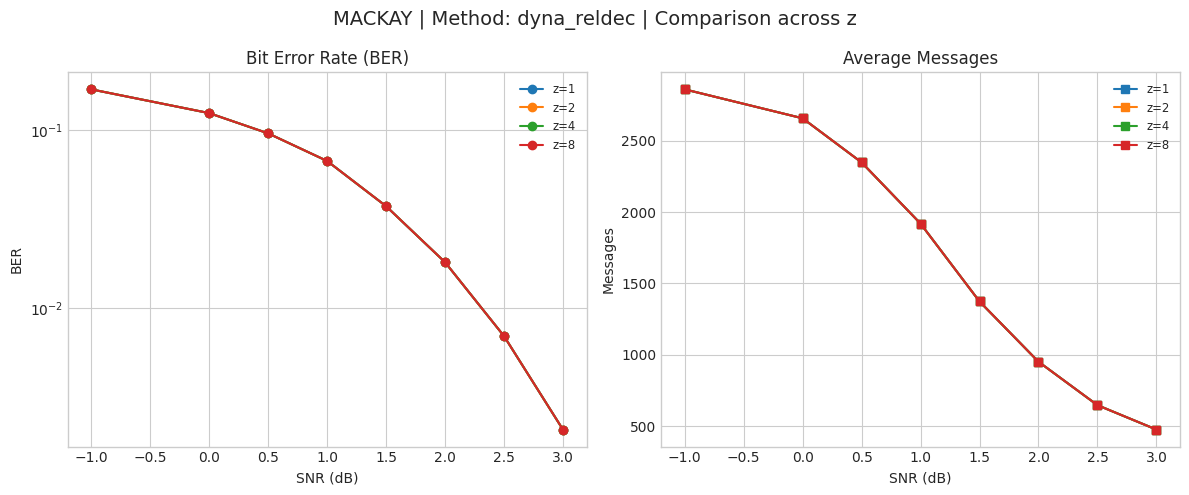

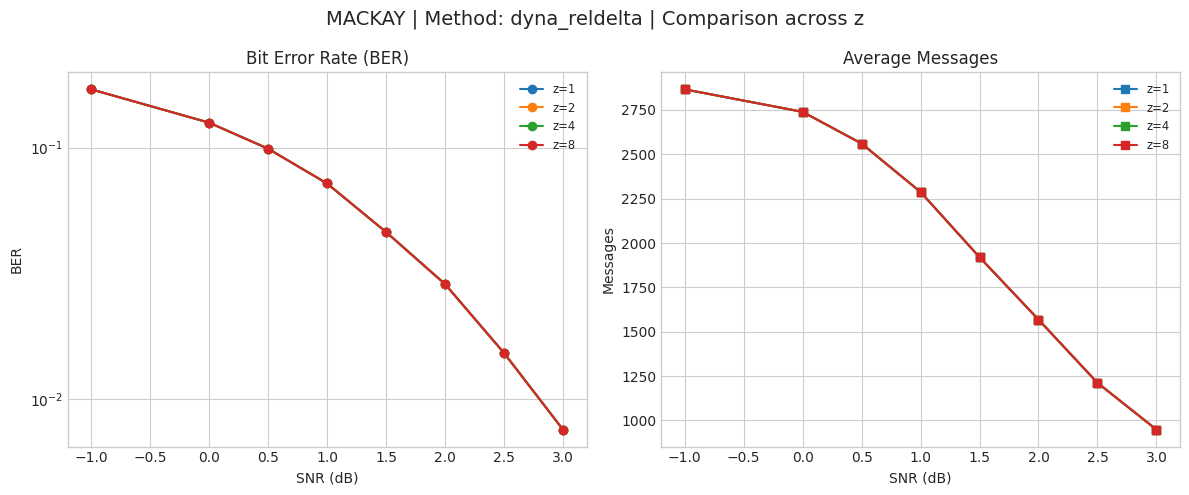

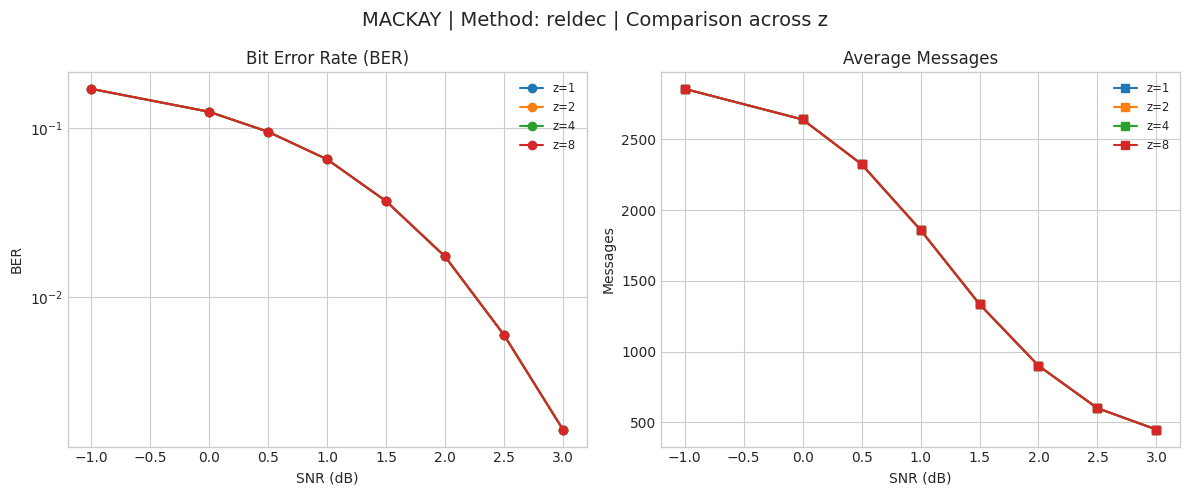

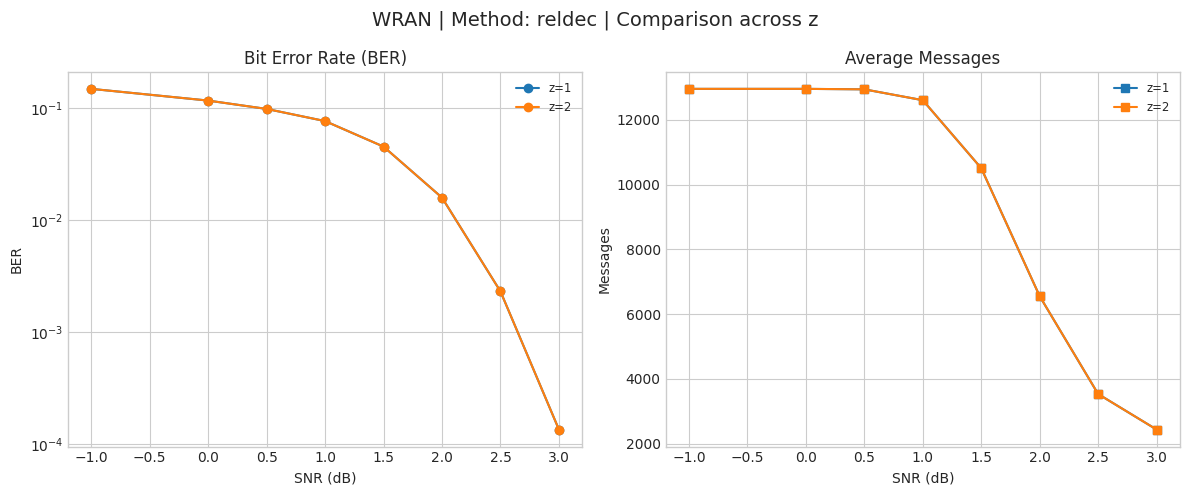


=== METHOD-SWEEP PLOTS ===


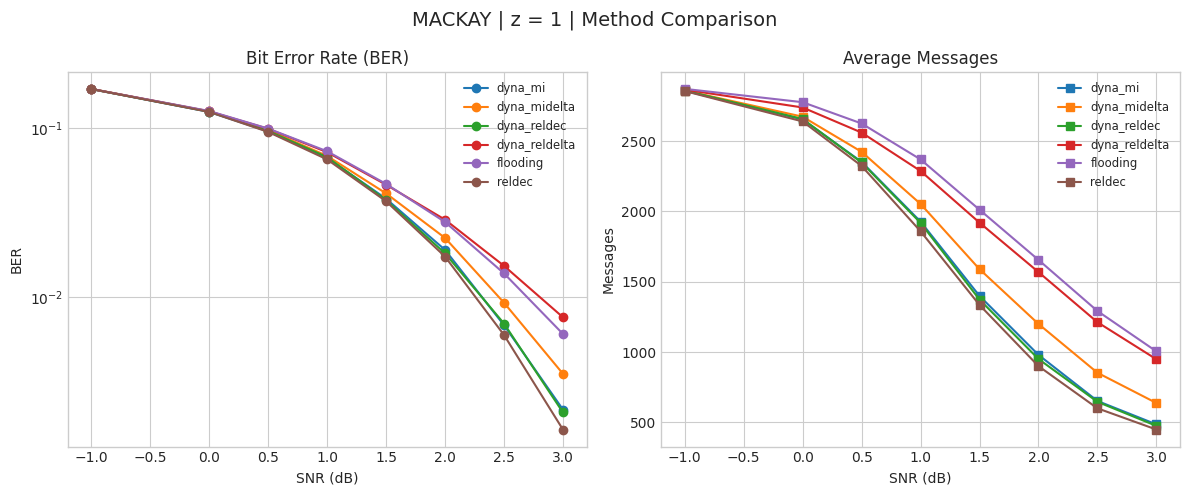

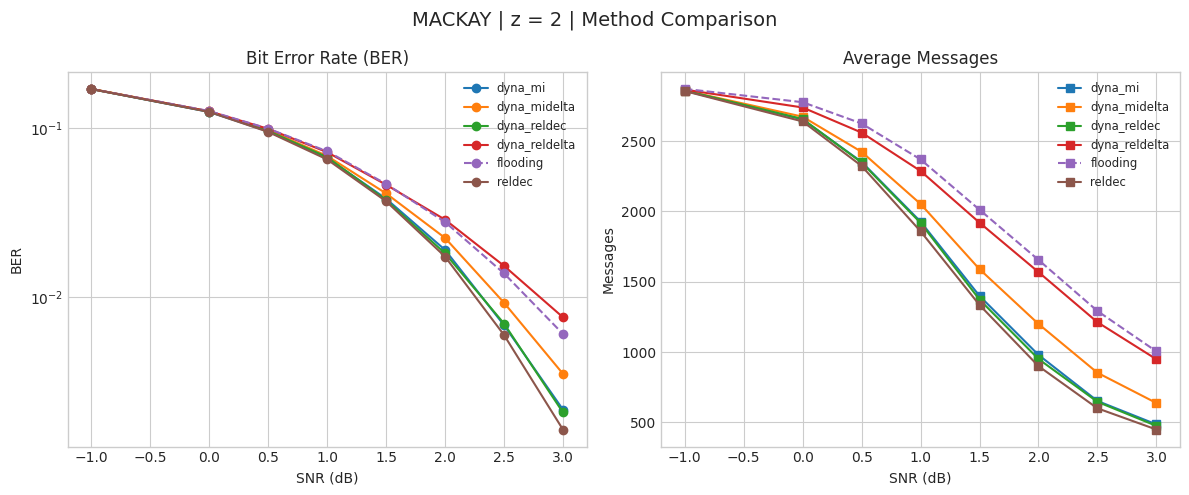

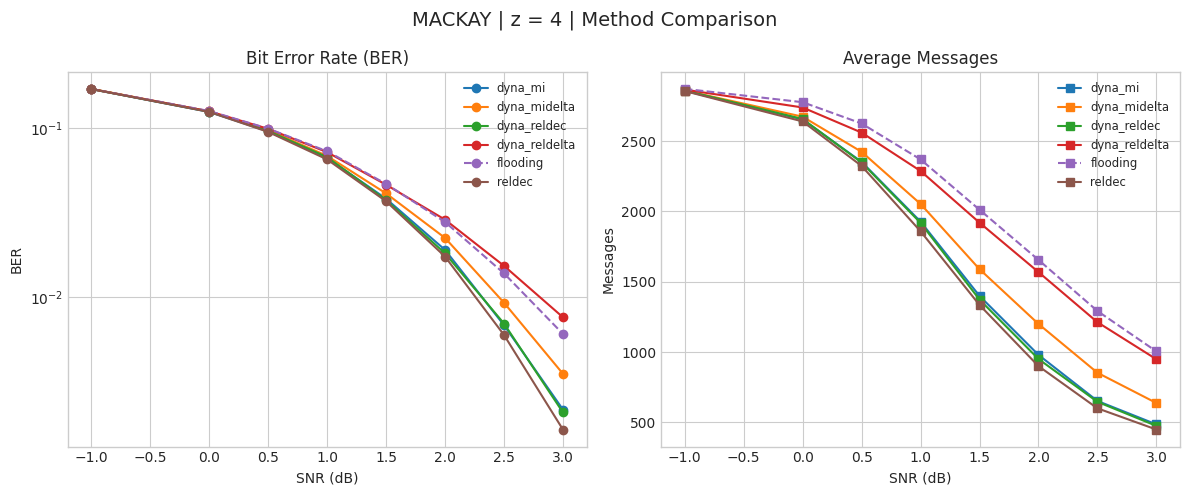

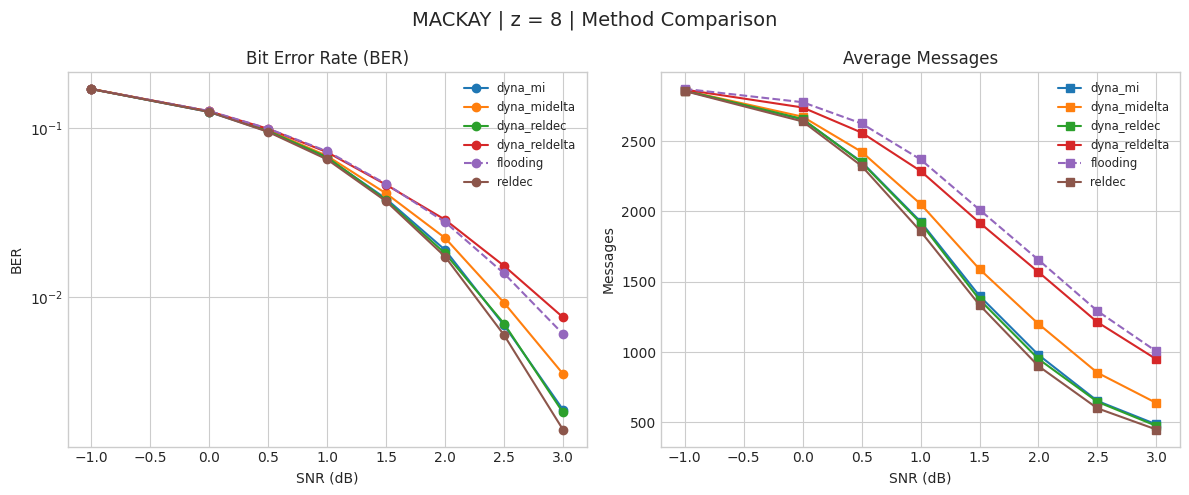

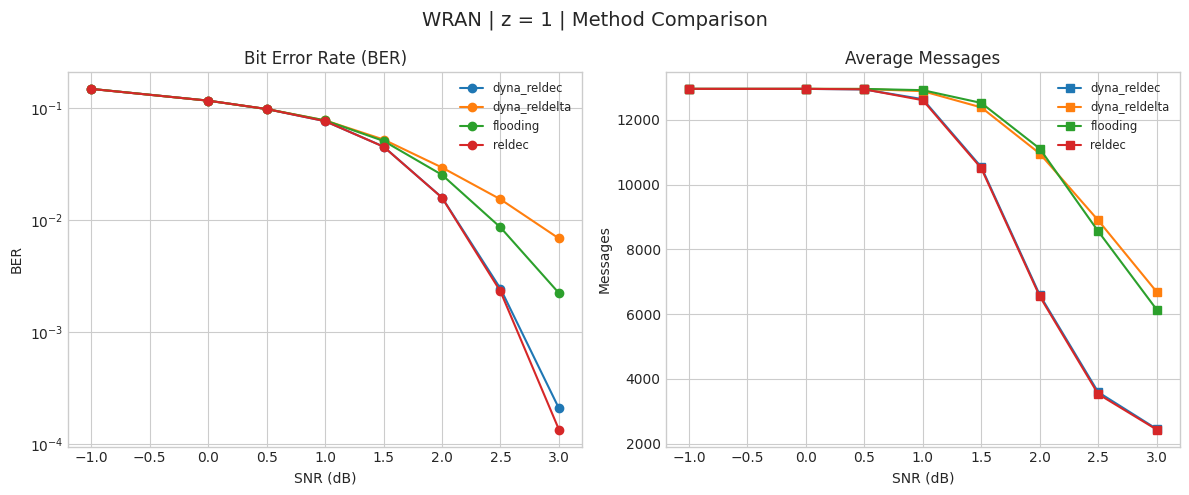

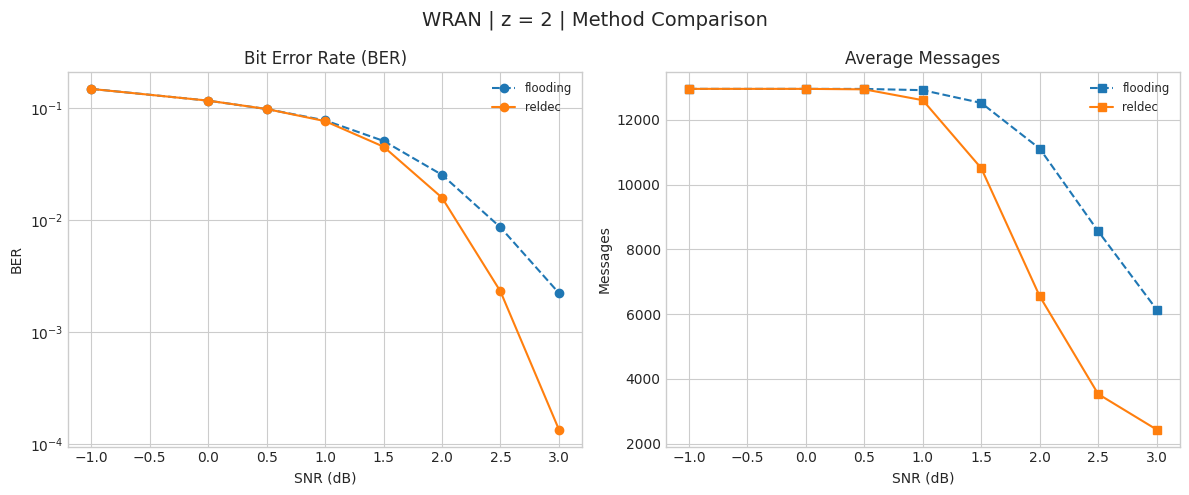

In [2]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt

# Optional: nice styling for notebooks
plt.style.use('seaborn-v0_8-whitegrid')
RESULTS_DIR = 'RELDEC/results/dynami_verification_1000'

def load_data():
    dfs = []
    for f in sorted(glob.glob(f'{RESULTS_DIR}/*.csv')):
        try:
            df = pd.read_csv(f)
            name = os.path.basename(f).replace('.csv', '')
            parts = name.rsplit('_z', 1)
            matrix_method = parts[0]
            z_val = int(parts[1]) if len(parts) > 1 else 1
            matrix = matrix_method.split('_')[0]
            method = matrix_method.split('_', 1)[1] if '_' in matrix_method else matrix_method
            
            df['matrix'] = matrix
            df['method'] = method
            df['z'] = z_val
            dfs.append(df)
        except Exception as e:
            pass

    if not dfs:
        print("No CSV results found yet.")
        return pd.DataFrame()

    return pd.concat(dfs, ignore_index=True)

def display_z_sweeps(all_df):
    """Plot BER and Avg Messages across different z values for a fixed method and matrix."""
    for matrix in all_df['matrix'].unique():
        sub_matrix = all_df[all_df['matrix'] == matrix]
        for method in sub_matrix['method'].unique():
            if method == 'flooding':
                continue # flooding only has z=1
                
            sub_method = sub_matrix[sub_matrix['method'] == method]
            if len(sub_method['z'].unique()) <= 1:
                continue

            fig, axes = plt.subplots(1, 2, figsize=(12, 5))
            fig.suptitle(f'{matrix.upper()} | Method: {method} | Comparison across z', fontsize=14)
            
            for z in sorted(sub_method['z'].unique()):
                m_df = sub_method[sub_method['z'] == z].sort_values('snr_db')
                axes[0].plot(m_df['snr_db'], m_df['ber'], marker='o', label=f'z={z}')
                axes[1].plot(m_df['snr_db'], m_df['avg_messages'], marker='s', label=f'z={z}')

            axes[0].set(title='Bit Error Rate (BER)', xlabel='SNR (dB)', ylabel='BER', yscale='log')
            axes[1].set(title='Average Messages', xlabel='SNR (dB)', ylabel='Messages')
            for ax in axes: ax.legend(fontsize='small')
            
            plt.tight_layout()
            plt.show()

def display_method_sweeps(all_df):
    """Plot BER and Avg Messages across different methods for a fixed matrix and z."""
    for matrix in all_df['matrix'].unique():
        sub_matrix = all_df[all_df['matrix'] == matrix]
        flooding_df = sub_matrix[sub_matrix['method'] == 'flooding']
        
        for z in sorted(sub_matrix['z'].unique()):
            sub_z = sub_matrix[sub_matrix['z'] == z]
            
            baseline_methods = set()
            if z != 1 and not flooding_df.empty:
                sub_z = pd.concat([sub_z, flooding_df])
                baseline_methods.add('flooding')
                
            if len(sub_z['method'].unique()) <= 1:
                continue

            fig, axes = plt.subplots(1, 2, figsize=(12, 5))
            fig.suptitle(f'{matrix.upper()} | z = {z} | Method Comparison', fontsize=14)
            
            for method in sorted(sub_z['method'].unique()):
                m_df = sub_z[sub_z['method'] == method].sort_values('snr_db')
                fmt = '--' if method in baseline_methods else '-'
                axes[0].plot(m_df['snr_db'], m_df['ber'], marker='o', linestyle=fmt, label=method)
                axes[1].plot(m_df['snr_db'], m_df['avg_messages'], marker='s', linestyle=fmt, label=method)

            axes[0].set(title='Bit Error Rate (BER)', xlabel='SNR (dB)', ylabel='BER', yscale='log')
            axes[1].set(title='Average Messages', xlabel='SNR (dB)', ylabel='Messages')
            for ax in axes: ax.legend(fontsize='small')
            
            plt.tight_layout()
            plt.show()

# Run it!
df = load_data()
if not df.empty:
    print("=== Z-SWEEP PLOTS ===")
    display_z_sweeps(df)
    
    print("\n=== METHOD-SWEEP PLOTS ===")
    display_method_sweeps(df)
